In [ ]:
# Standard library
import json
import os
import sys
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy import stats
from scipy.interpolate import interp1d

# Root dir
ROOT = Path(os.getcwd()).resolve()
sys.path.append(str(ROOT/'src'))

# Local
from utils import gaussian_smoothing

## Training Loss vs Compute

### Training data

In [2]:
# results directory
lr = '0.0000016'
dir_path = ROOT/f'results/slim_pajama/lr_{lr}/'
    
# smoothing parameters
sigma = 70
window_size = 3 * sigma

# data dict
flops_and_losses = {}

for file_path in dir_path.iterdir():
    if file_path.is_file():
        with open(file_path, 'r') as file:
            # load results dict
            results = json.load(file)

            # params
            n_params = results['n_params']

            # flops
            total_batches = results['total_batches']
            total_flops = results['n_flops']
            flops = np.linspace(0, total_flops, total_batches)
            flops = flops[window_size:-window_size + 1]

            # smoothed losses
            losses = results['losses']
            # smooth_losses = moving_average(losses, window_size)
            smooth_losses = gaussian_smoothing(losses, sigma, window_size)

            # create dict entry if it doesn't exist
            if n_params not in flops_and_losses:
                flops_and_losses[n_params] = []
                
            # add to dict
            flops_and_losses[n_params].append((flops, smooth_losses))

### Pareto frontier

In [3]:
# interpolation functions
min_flops = 1e15
max_flops = float('-inf')
interp_fcns = []
for f_l_lists in flops_and_losses.values():
    for f_list, l_list in f_l_lists:
        max_flops = max(max_flops, f_list[-1])
        interp_fcns.append(interp1d(f_list, l_list, bounds_error=False, 
                                    fill_value=float('inf')))
print(f'Min flops = {min_flops:.2e}')
print(f'Max flops = {max_flops:.2e}')

# pareto frontier
all_flops = np.logspace(np.log10(min_flops), np.log10(max_flops), 100)[1:-1]
pareto = {f: min(fcn(f) for fcn in interp_fcns) for f in all_flops}

# line of best fit
regress = stats.linregress(np.log2(all_flops), np.log2(list(pareto.values())))
pareto_lobf = 2 ** (regress[0] * np.log2(all_flops) + regress[1])

Min flops = 1.00e+15
Max flops = 5.77e+17


### Plot

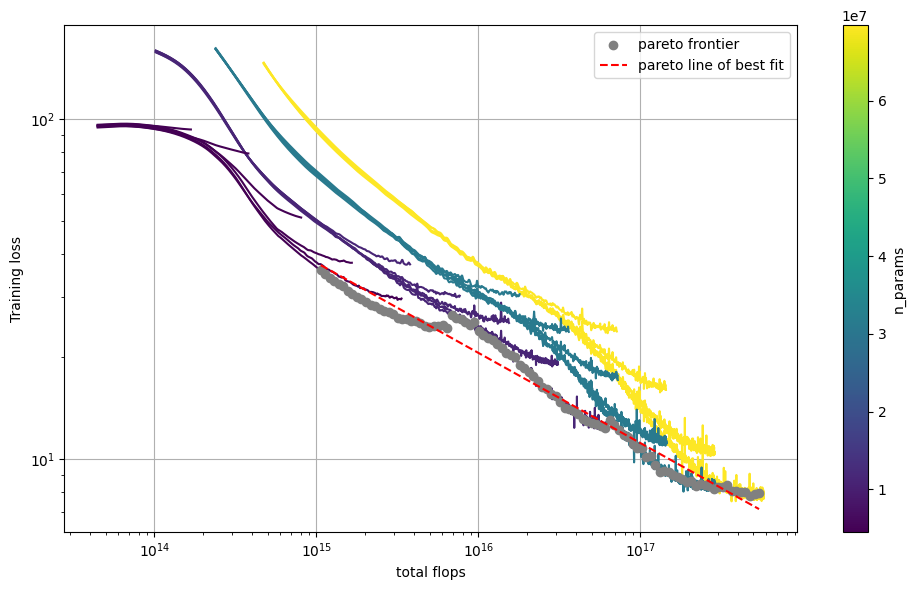

In [22]:
# create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# colourmap
cmap = plt.cm.viridis
norm = Normalize(vmin=min(flops_and_losses), vmax=max(flops_and_losses))

# plot training curves
for n_params in flops_and_losses:
    for flops, smooth_losses in flops_and_losses[n_params]:
        ax.plot(flops, smooth_losses, color=cmap(norm(n_params)), markersize=2)

# plot pareto frontier
ax.scatter(pareto.keys(), pareto.values(), color='gray', zorder=3, label='pareto frontier')
ax.plot(all_flops, pareto_lobf, ls='--', color='red', label='pareto line of best fit', zorder=4)
    
# colourbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('n_params')

# labels
ax.set_xlabel('total flops')
ax.set_ylabel('Training loss')
ax.grid(True)
ax.legend()

# log scale
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

### Extrapolate pareto frontier

In [8]:
def pareto_extrapolate(flops):
    slope = regress[0]
    intercept = regress[1]

    return 2 ** (slope * np.log2(flops) + intercept)

print('Expected pareto losses:')
for f in [1e19, 1e20, 1e21, 1e22, 1e23]:
    expected_loss = pareto_extrapolate(f)
    print(f'  Flops = {f:.2e} ==> Pareto loss = {expected_loss:.2f}')

Expected pareto losses:
  Flops = 1.00e+19 ==> Pareto loss = 3.30
  Flops = 1.00e+20 ==> Pareto loss = 1.79
  Flops = 1.00e+21 ==> Pareto loss = 0.97
  Flops = 1.00e+22 ==> Pareto loss = 0.53
  Flops = 1.00e+23 ==> Pareto loss = 0.29


## Optimal scaling of model size and training data

## Performance of T4 GPU

### Collect data

For each training run collect three data points:
1. n_params
2. n_tokens
2. flops / s 

In [33]:
# results directory
lr = '0.0000016'
dir_path = ROOT/f'results/slim_pajama/lr_{lr}/'
    
# data list
data_list = []

# collect data
for file_path in dir_path.iterdir():
    if file_path.is_file():
        with open(file_path, 'r') as file:
            # load results dict
            results = json.load(file)

            # use if device is cuda
            if results['model_hyperparameters']['device'] == 'cuda':
                # get data
                n_params = results['n_params']
                n_tokens = results['n_tokens']
                flops_per_s = results['n_flops'] / results['train_time']

                # add to data list
                data_list.append((n_params, n_tokens, flops_per_s))

### Plot 

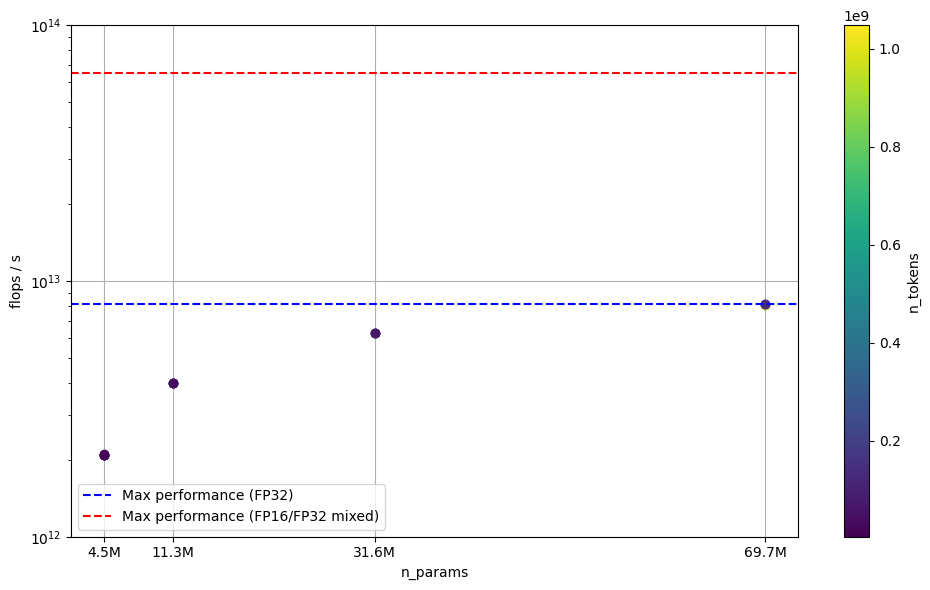

In [34]:
# create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# colourmap (represents n_tokens)
cmap = plt.cm.viridis
min_toks = min(n_toks for _, n_toks, _ in data_list)
max_toks = max(n_toks for _, n_toks, _ in data_list)
norm = Normalize(vmin=min_toks, vmax=max_toks)

# plot training curves
for n_params, n_tokens, flops_per_s in data_list:
    ax.plot(n_params, flops_per_s, 'o', color=cmap(norm(n_tokens)))
    
# colourbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('n_tokens')

# optimal performance
max_flops_fp32 = 8.1e12
max_flops_mixed = 65e12
ax.axhline(max_flops_fp32, ls='--', color='blue', 
           label='Max performance (FP32)')
ax.axhline(max_flops_mixed, ls='--', color='red', 
           label='Max performance (FP16/FP32 mixed)')

# labels
ax.set_xlabel('n_params')
ax.set_ylabel('flops / s')
ax.set_xticks([4.5e6, 11.3e6, 31.2e6, 69.7e6])
ax.set_xticklabels(['4.5M', '11.3M', '31.6M', '69.7M'])
ax.set_ylim(1e12, 1e14)
ax.grid(True)
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## CPU vs MPS vs T4 GPU